# Notebook 4 — PyTorch Custom Dataset & DataLoader

In [1]:
print("python")

python


In [2]:
import os
import cv2
import pandas as pd
import numpy as np
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from torchvision import transforms, datasets

In [3]:
import time
import shutil
import random
import numpy as np
from tqdm import tqdm

In [4]:
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [5]:
PROJECT_ROOT = ".."
RAW_DIR = os.path.join(PROJECT_ROOT, "data", "raw", "images_dataSAT")
dir_agri = os.path.join(RAW_DIR, "class_1_agri")
dir_non_agri = os.path.join(RAW_DIR, "class_0_non_agri")
(RAW_DIR, dir_agri, dir_non_agri)

('..\\data\\raw\\images_dataSAT',
 '..\\data\\raw\\images_dataSAT\\class_1_agri',
 '..\\data\\raw\\images_dataSAT\\class_0_non_agri')

- Load binary image data (Agri vs Non-Agri)
- Custom Dataset: paths + labels, shuffle, (img, label)
- Transforms: resize + augment + normalize
- ImageFolder: auto-label from folders
- DataLoader: batching (8), shuffle
- Output: images [B,3,H,W], labels [B]
- Visualize: denormalize + plot grid

In [6]:
class CustomeBinaryClassification(Dataset):
    def __init__(self, non_agri_dir, agri_dir, transform=None):
        self.transform = transform
        self.image_paths = []
        self.labels = []

        for fname in os.listdir(non_agri_dir):
            self.image_paths.append(os.path.join(non_agri_dir, fname))
            self.labels.append(0)
            
        for fname in os.listdir(agri_dir):
            self.image_paths.append(os.path.join(agri_dir, fname))
            self.labels.append(1)

        temp = list(zip(self.image_paths, self.labels))
        np.random.shuffle(temp)
        self.image_paths, self.labels = zip(*temp)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        image = Image.open(image_path).convert("RGB") 
        
        label = self.labels[idx]
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

In [7]:
test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(), # Converts PIL Image to a tensor
    transforms.Normalize(mean = [0.5, 0.5, 0.5], std = [0.5, 0.5, 0.5]) # Normalize
])

In [8]:
custom_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(45),
    transforms.ToTensor(), 
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

In [9]:
imagefolder_dataset = datasets.ImageFolder(root=RAW_DIR, transform=custom_transform)

In [10]:
print(f"Classes found by ImageFolder: {imagefolder_dataset.classes}")
print(f"Class to index mapping: {imagefolder_dataset.class_to_idx}")

Classes found by ImageFolder: ['class_0_non_agri', 'class_1_agri']
Class to index mapping: {'class_0_non_agri': 0, 'class_1_agri': 1}


In [11]:
BATCH_SIZE = 8 

custom_dataset = CustomeBinaryClassification(dir_non_agri, dir_agri, transform=custom_transform)
custom_loader = DataLoader(custom_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

imagefolder_loader = DataLoader(imagefolder_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

print("DataLoaders created successfully!")

DataLoaders created successfully!


On Windows, Jupyter can't spawn background worker processes, so num_workers=2 causes everything to freeze indefinitely.

In [12]:
images_custom, labels_custom = next(iter(custom_loader))

print(f"Images batch shape (Custom loader): {images_custom.shape}") 
print(f"Labels batch shape (Custom loader): {labels_custom.shape}")

Images batch shape (Custom loader): torch.Size([8, 3, 64, 64])
Labels batch shape (Custom loader): torch.Size([8])


In [13]:
images_inbuilt, labels_inbuilt = next(iter(imagefolder_loader))

print(f"Images batch shape (PyTorch in-built loader): {images_inbuilt.shape}") 
print(f"Labels batch shape (PyTorch in-built loader): {labels_inbuilt.shape}")

Images batch shape (PyTorch in-built loader): torch.Size([8, 3, 64, 64])
Labels batch shape (PyTorch in-built loader): torch.Size([8])


In [14]:
def imshow(img):
    img = img.detach().cpu()
    img = img / 2 + 0.5
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0))) # Convert from C,H,W to H,W,C

The .detach().cpu() is still a good practice to keep — it explicitly tells PyTorch "don't track gradients, make sure this is on CPU" before converting to numpy. Safer to have it.

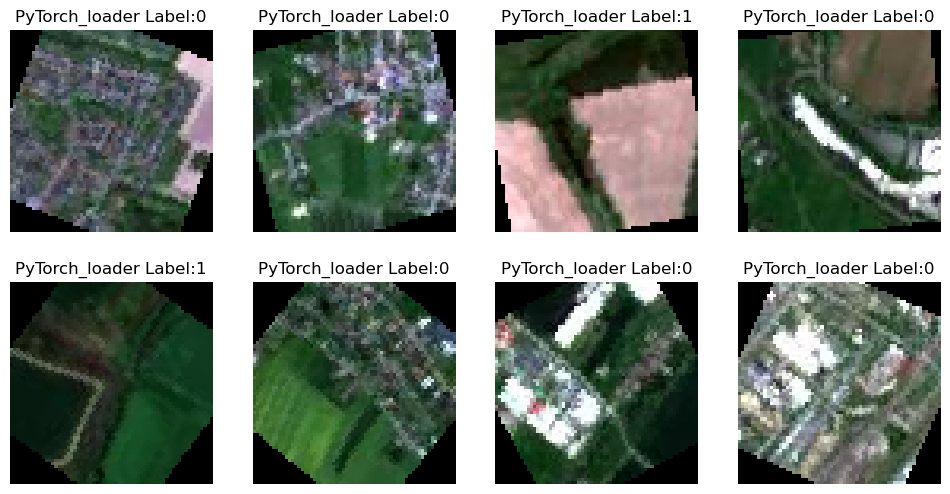

In [15]:
plt.figure(figsize = (12, 6))
for i in range(BATCH_SIZE):
    ax = plt.subplot(2, 4, i + 1)
    imshow(images_inbuilt[i])
    plt.title(f"PyTorch_loader Label:{labels_inbuilt[i].item()}")
    plt.axis("off")  
plt.show()

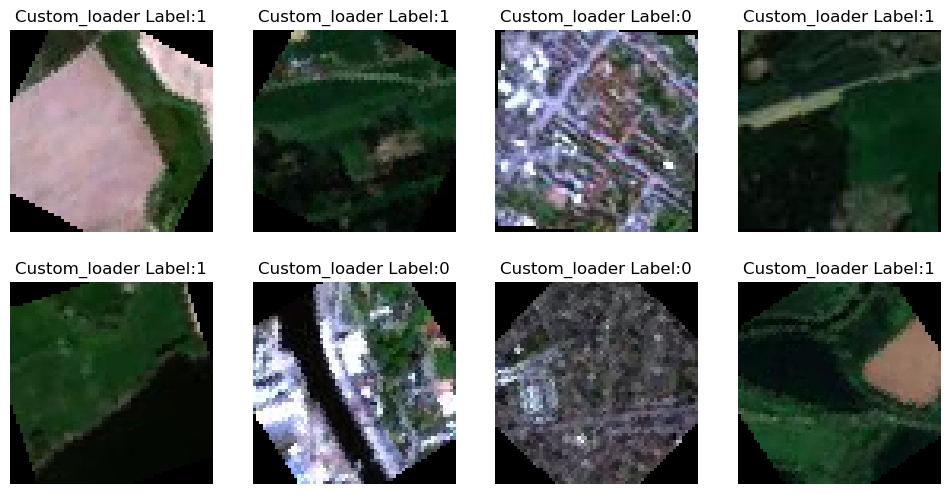

In [16]:
plt.figure(figsize=(12, 6))
for i in range(BATCH_SIZE):
    ax = plt.subplot(2, 4, i + 1)
    imshow(images_custom[i])
    plt.title(f"Custom_loader Label:{labels_custom[i].item()}")
    plt.axis("off")

In [17]:
def set_seed(seed: int = 42) -> None:
    """Seed Python, NumPy, and PyTorch (CPU & all GPUs) and
    make cuDNN run in deterministic mode."""
    # ---- Python and NumPy -------------------------------------------
    random.seed(seed)
    np.random.seed(seed)

    # ---- PyTorch (CPU  &  GPU) --------------------------------------
    torch.manual_seed(seed)            
    torch.cuda.manual_seed_all(seed)   

    # ---- cuDNN: force repeatable convolutions -----------------------
    torch.backends.cudnn.deterministic = True 
    torch.backends.cudnn.benchmark     = False 

In [18]:
SEED = 42
set_seed(SEED)
print(f"Global seed set to {SEED} — main process is now deterministic.")

Global seed set to 42 — main process is now deterministic.


In [19]:
def worker_init_fn(worker_id: int) -> None:
    """Re-seed each DataLoader worker so their RNGs don't collide."""
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed) 
    random.seed(worker_seed)
    torch.manual_seed(worker_seed)

In [20]:
(RAW_DIR, dir_agri, dir_non_agri)

('..\\data\\raw\\images_dataSAT',
 '..\\data\\raw\\images_dataSAT\\class_1_agri',
 '..\\data\\raw\\images_dataSAT\\class_0_non_agri')

In [21]:
dataset_path = os.path.join(RAW_DIR)
print(dataset_path)

..\data\raw\images_dataSAT


In [38]:
img_size = 64
batch_size = 128
lr = 0.001
epochs = 3 # set to low number for your convenience. You can change this to any number of your liking
model_name = "best_model.pytorch.h5"
num_classes = 2 #number of classes in the dataset

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device used is {device}")


Device used is cuda


In [39]:
train_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.RandomRotation(40),
    transforms.RandomHorizontalFlip(),
    transforms.RandomAffine(0, shear=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [40]:
val_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [41]:
full_dataset = datasets.ImageFolder(dataset_path, transform=train_transform)

In [42]:
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])
val_dataset.dataset.transform = val_transform

In [43]:
train_loader = DataLoader(
    train_dataset, 
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    worker_init_fn=worker_init_fn
)

In [44]:
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    worker_init_fn=worker_init_fn
)

In [45]:
# --- MODEL ---
model = nn.Sequential(
    # Conv Block 1
    nn.Conv2d(3, 32, 5, padding=2), nn.ReLU(),
    nn.MaxPool2d(2), nn.BatchNorm2d(32),
                        
    # Conv Block 2-6
    nn.Conv2d(32, 64, 5, padding=2), nn.ReLU(), nn.MaxPool2d(2), nn.BatchNorm2d(64),
    nn.Conv2d(64, 128, 5, padding=2), nn.ReLU(), nn.MaxPool2d(2), nn.BatchNorm2d(128),
    nn.Conv2d(128, 256, 5, padding=2), nn.ReLU(), nn.MaxPool2d(2), nn.BatchNorm2d(256),
    nn.Conv2d(256, 512, 5, padding=2), nn.ReLU(), nn.MaxPool2d(2), nn.BatchNorm2d(512),
    nn.Conv2d(512, 1024, 5, padding=2), nn.ReLU(), nn.MaxPool2d(2), nn.BatchNorm2d(1024),
                        
    # Classifier
    nn.AdaptiveAvgPool2d(1), nn.Flatten(),
    nn.Linear(1024, 2048), nn.ReLU(), nn.BatchNorm1d(2048), nn.Dropout(0.4),
    nn.Linear(2048, num_classes)
).to(device)

In [46]:
# --- TRAINING SETUP ---
#criterion = nn.BCEWithLogitsLoss()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=lr)
best_loss = float('inf')
loss_history = {'train': [], 'val': []}
acc_history = {'train': [], 'val': []}


In [47]:
print(f"Training on : ==={device}=== with batch size: {batch_size} & lr: {lr}")

# --- TRAINING LOOP ---
for epoch in range(epochs):
    # Training Phase
    start_time = time.time() # to get the training time for each epoch
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0  # for the training metrics
    for batch_idx, (images, labels) in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")):
        images, labels = images.to(device), labels.to(device)  # labels as integer class indices
        optimizer.zero_grad()
        outputs = model(images)  # outputs are raw logits
        loss = criterion(outputs, labels)  # criterion is nn.CrossEntropyLoss
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)
  
    # Synchronize CUDA before stopping timer (if using GPU)
    if device == 'cuda':
        torch.cuda.synchronize()

    # Validation Phase
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0 #  for the validation metrics
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            val_loss += criterion(outputs, labels).item()
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)
  
    # Save the best model
    avg_val_loss = val_loss/len(val_loader)
    if avg_val_loss < best_loss:
        best_loss = avg_val_loss
        torch.save(model.state_dict(), model_name)
    
    # Store metrics
    loss_history['train'].append(train_loss/len(train_loader))
    loss_history['val'].append(val_loss/len(val_loader))
    acc_history['train'].append(train_correct/train_total)
    acc_history['val'].append(val_correct/val_total)
    
    #print(f"Epoch {epoch+1}/{epochs}")
    print(f"Train Loss: {loss_history['train'][-1]:.4f} | Val Loss: {loss_history['val'][-1]:.4f}")
    print(f"Train Acc: {acc_history['train'][-1]:.4f} | Val Acc: {acc_history['val'][-1]:.4f}")
    epoch_time = time.time() - start_time
    print(f"Epoch {epoch+1} training completed in {epoch_time:.2f} seconds\n") 



Training on : ===cuda=== with batch size: 128 & lr: 0.001


Epoch 1/3: 100%|███████████████████████████████████████████████████████████████████████| 38/38 [00:07<00:00,  5.00it/s]


Train Loss: 0.3335 | Val Loss: 0.0551
Train Acc: 0.9235 | Val Acc: 0.9850
Epoch 1 training completed in 9.26 seconds



Epoch 2/3: 100%|███████████████████████████████████████████████████████████████████████| 38/38 [00:07<00:00,  4.79it/s]


Train Loss: 0.0240 | Val Loss: 0.0106
Train Acc: 0.9915 | Val Acc: 0.9950
Epoch 2 training completed in 9.45 seconds



Epoch 3/3: 100%|███████████████████████████████████████████████████████████████████████| 38/38 [00:07<00:00,  4.94it/s]


Train Loss: 0.0160 | Val Loss: 0.0108
Train Acc: 0.9940 | Val Acc: 0.9942
Epoch 3 training completed in 9.03 seconds



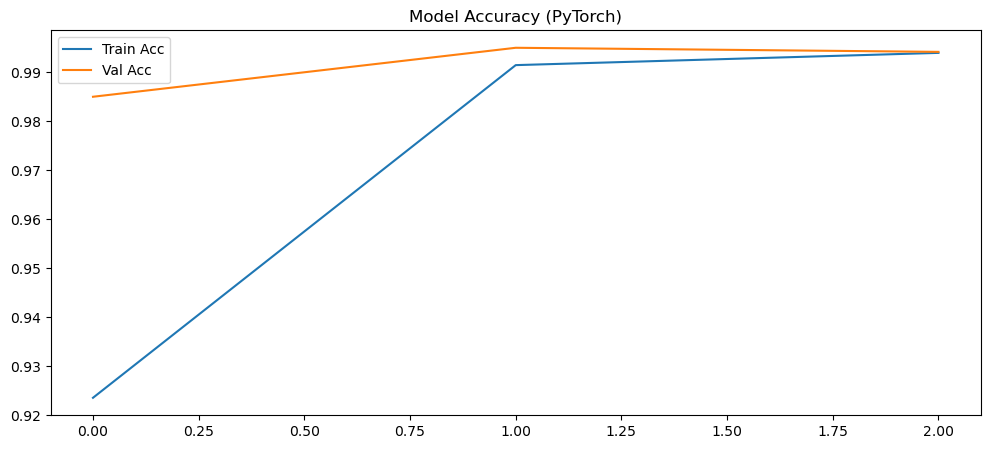

In [48]:
plt.figure(figsize=(12, 5))
plt.plot(acc_history['train'], label='Train Acc')
plt.plot(acc_history['val'], label='Val Acc')
plt.title('Model Accuracy (PyTorch)')
plt.legend()
plt.show()

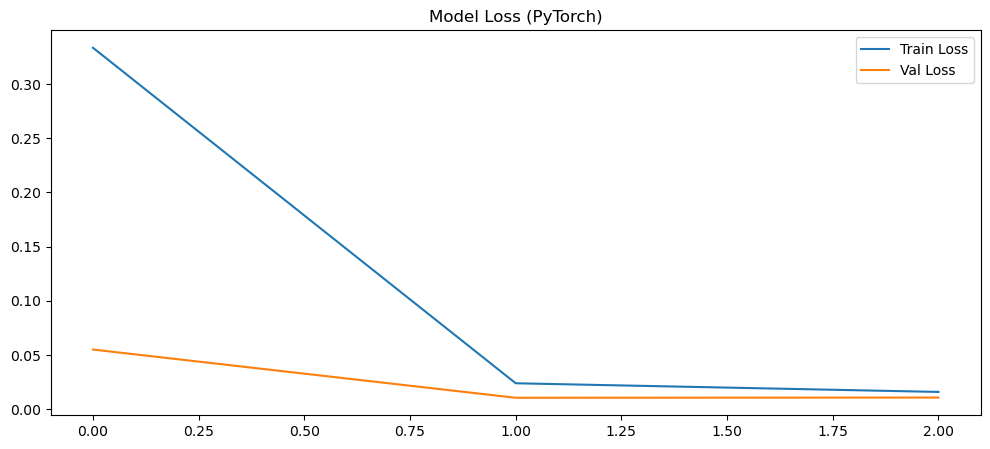

In [49]:
plt.figure(figsize=(12, 5))
plt.plot(loss_history['train'], label='Train Loss')
plt.plot(loss_history['val'], label='Val Loss')
plt.title('Model Loss (PyTorch)')
plt.legend()
plt.show()

In [50]:
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy().flatten())
        all_labels.extend(labels.numpy())

In [51]:
accuracy = accuracy_score(all_labels, all_preds)
print(f"The accuracy of the model is: {accuracy:.4f}")

The accuracy of the model is: 0.9942
